In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
orders = pd.read_csv('../data/List of Orders.csv')
details = pd.read_csv('../data/Order Details.csv')
targets = pd.read_csv('../data/Sales target.csv')

# First look
print("=== ORDERS ===")
print(f"Rows & Columns: {orders.shape}")
print(orders.head())

print("\n=== ORDER DETAILS ===")
print(f"Rows & Columns: {details.shape}")
print(details.head())

=== ORDERS ===
Rows & Columns: (560, 5)
  Order ID  Order Date CustomerName           State       City
0  B-25601  01-04-2018       Bharat         Gujarat  Ahmedabad
1  B-25602  01-04-2018        Pearl     Maharashtra       Pune
2  B-25603  03-04-2018        Jahan  Madhya Pradesh     Bhopal
3  B-25604  03-04-2018       Divsha       Rajasthan     Jaipur
4  B-25605  05-04-2018      Kasheen     West Bengal    Kolkata

=== ORDER DETAILS ===
Rows & Columns: (1500, 6)
  Order ID  Amount  Profit  Quantity     Category      Sub-Category
0  B-25601  1275.0 -1148.0         7    Furniture         Bookcases
1  B-25601    66.0   -12.0         5     Clothing             Stole
2  B-25601     8.0    -2.0         3     Clothing       Hankerchief
3  B-25601    80.0   -56.0         4  Electronics  Electronic Games
4  B-25602   168.0  -111.0         2  Electronics            Phones


In [2]:
# Check for missing values
print("=== MISSING VALUES ===")
print("Orders missing values:")
print(orders.isnull().sum())

print("\nDetails missing values:")
print(details.isnull().sum())

# Check data types
print("\n=== DATA TYPES ===")
print(orders.dtypes)
print(details.dtypes)

# Basic stats
print("\n=== BASIC STATS (Details) ===")
print(details[['Amount', 'Profit', 'Quantity']].describe())

=== MISSING VALUES ===
Orders missing values:
Order ID        60
Order Date      60
CustomerName    60
State           60
City            60
dtype: int64

Details missing values:
Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
dtype: int64

=== DATA TYPES ===
Order ID        object
Order Date      object
CustomerName    object
State           object
City            object
dtype: object
Order ID         object
Amount          float64
Profit          float64
Quantity          int64
Category         object
Sub-Category     object
dtype: object

=== BASIC STATS (Details) ===
            Amount       Profit     Quantity
count  1500.000000  1500.000000  1500.000000
mean    287.668000    15.970000     3.743333
std     461.050488   169.140565     2.184942
min       4.000000 -1981.000000     1.000000
25%      45.000000    -9.250000     2.000000
50%     118.000000     9.000000     3.000000
75%     322.000000    38.000000     5.000000
ma

In [3]:
# Step 1: Drop rows with missing values in orders
print(f"Orders before cleaning: {orders.shape}")
orders = orders.dropna()
print(f"Orders after cleaning: {orders.shape}")

# Step 2: Convert Order Date to proper date format
orders['Order Date'] = pd.to_datetime(orders['Order Date'], dayfirst=True)

# Step 3: Extract Month and Year for time analysis
orders['Month'] = orders['Order Date'].dt.month_name()
orders['Year'] = orders['Order Date'].dt.year

# Step 4: Merge both tables for combined analysis
df = pd.merge(details, orders, on='Order ID', how='inner')

print(f"\nMerged dataset shape: {df.shape}")
print("\nFirst look at merged data:")
print(df.head())

print("\nColumns available:")
print(df.columns.tolist())

Orders before cleaning: (560, 5)
Orders after cleaning: (500, 5)

Merged dataset shape: (1500, 12)

First look at merged data:
  Order ID  Amount  Profit  Quantity     Category      Sub-Category  \
0  B-25601  1275.0 -1148.0         7    Furniture         Bookcases   
1  B-25601    66.0   -12.0         5     Clothing             Stole   
2  B-25601     8.0    -2.0         3     Clothing       Hankerchief   
3  B-25601    80.0   -56.0         4  Electronics  Electronic Games   
4  B-25602   168.0  -111.0         2  Electronics            Phones   

  Order Date CustomerName        State       City  Month  Year  
0 2018-04-01       Bharat      Gujarat  Ahmedabad  April  2018  
1 2018-04-01       Bharat      Gujarat  Ahmedabad  April  2018  
2 2018-04-01       Bharat      Gujarat  Ahmedabad  April  2018  
3 2018-04-01       Bharat      Gujarat  Ahmedabad  April  2018  
4 2018-04-01        Pearl  Maharashtra       Pune  April  2018  

Columns available:
['Order ID', 'Amount', 'Profit', 'Qu

In [4]:
# Sales and Profit by Category
category_analysis = df.groupby('Category')[['Amount', 'Profit']].sum().reset_index()
category_analysis = category_analysis.sort_values('Amount', ascending=False)
print("=== SALES & PROFIT BY CATEGORY ===")
print(category_analysis)

# Top 10 States by Sales
state_sales = df.groupby('State')['Amount'].sum().reset_index()
state_sales = state_sales.sort_values('Amount', ascending=False).head(10)
print("\n=== TOP 10 STATES BY SALES ===")
print(state_sales)

# Monthly Sales Trend
monthly = df.groupby('Month')['Amount'].sum().reset_index()
print("\n=== MONTHLY SALES ===")
print(monthly.sort_values('Amount', ascending=False))

# Loss-making Sub-Categories
sub_profit = df.groupby('Sub-Category')['Profit'].sum().reset_index()
losses = sub_profit[sub_profit['Profit'] < 0].sort_values('Profit')
print("\n=== LOSS-MAKING SUB-CATEGORIES ===")
print(losses)

=== SALES & PROFIT BY CATEGORY ===
      Category    Amount   Profit
1  Electronics  165267.0  10494.0
0     Clothing  139054.0  11163.0
2    Furniture  127181.0   2298.0

=== TOP 10 STATES BY SALES ===
             State    Amount
10  Madhya Pradesh  105140.0
11     Maharashtra   95348.0
2            Delhi   22531.0
17   Uttar Pradesh   22359.0
14       Rajasthan   21149.0
4          Gujarat   21058.0
13          Punjab   16786.0
8        Karnataka   15058.0
18     West Bengal   14086.0
9          Kerala    13459.0

=== MONTHLY SALES ===
        Month   Amount
4     January  61439.0
7       March  58937.0
9    November  48086.0
3    February  38424.0
2    December  37579.0
0       April  32726.0
10    October  31615.0
1      August  30899.0
8         May  28545.0
11  September  26628.0
6        June  23658.0
5        July  12966.0

=== LOSS-MAKING SUB-CATEGORIES ===
        Sub-Category  Profit
15            Tables -4011.0
3   Electronic Games -1236.0


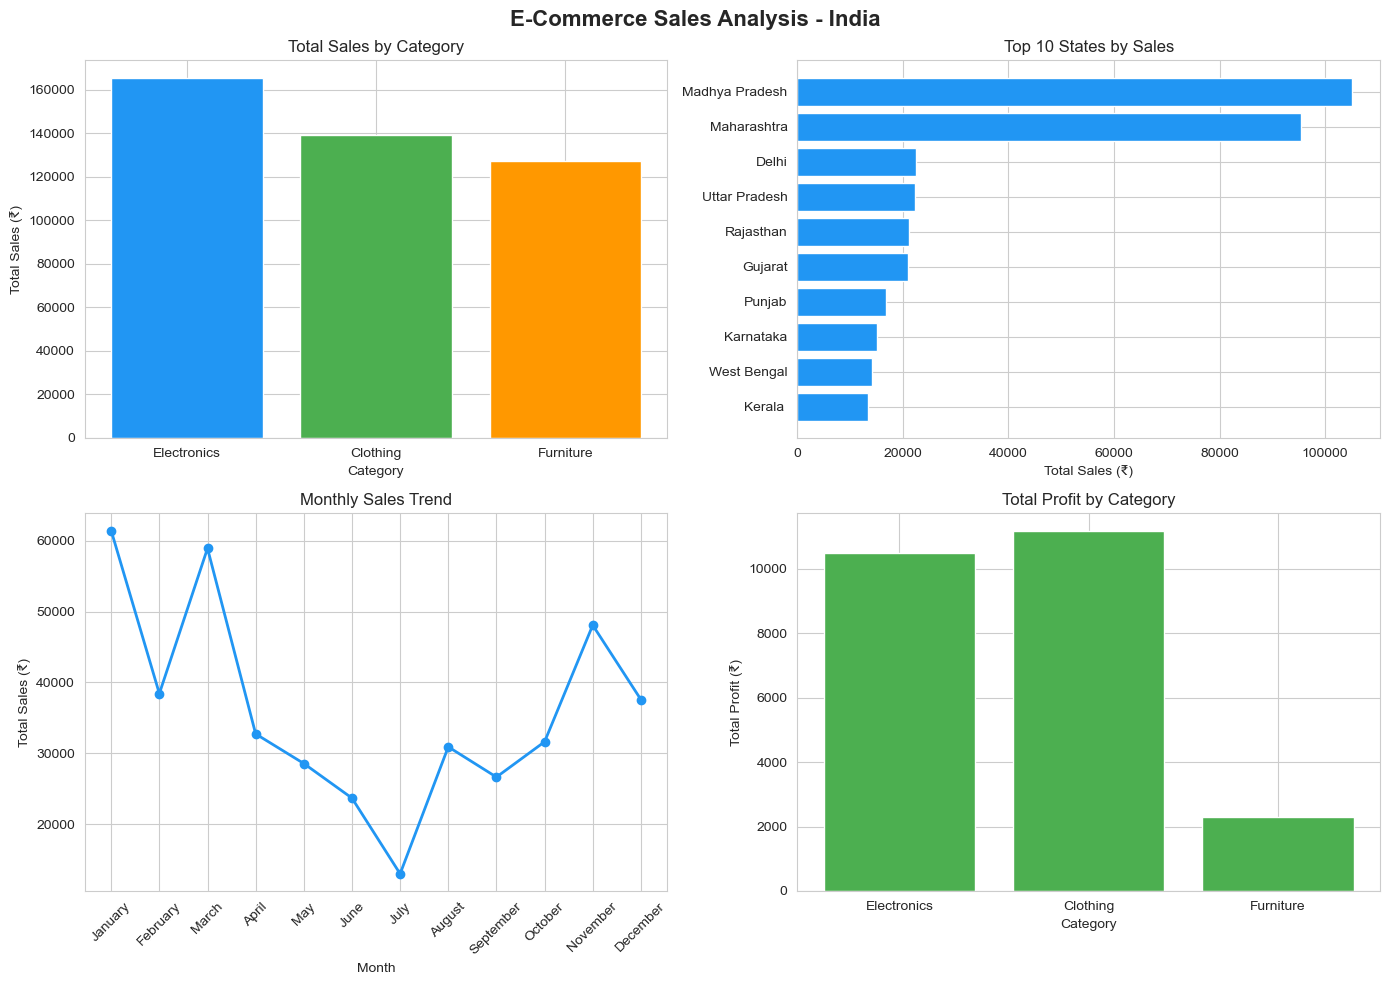

Chart saved to charts folder!


In [5]:
# Set style
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('E-Commerce Sales Analysis - India', fontsize=16, fontweight='bold')

# Chart 1: Sales by Category
axes[0,0].bar(category_analysis['Category'], category_analysis['Amount'], 
              color=['#2196F3', '#4CAF50', '#FF9800'])
axes[0,0].set_title('Total Sales by Category')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Total Sales (₹)')

# Chart 2: Top 10 States
axes[0,1].barh(state_sales['State'], state_sales['Amount'], color='#2196F3')
axes[0,1].set_title('Top 10 States by Sales')
axes[0,1].set_xlabel('Total Sales (₹)')
axes[0,1].invert_yaxis()

# Chart 3: Monthly Sales Trend
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly['Month'] = pd.Categorical(monthly['Month'], categories=month_order, ordered=True)
monthly = monthly.sort_values('Month')
axes[1,0].plot(monthly['Month'], monthly['Amount'], marker='o', color='#2196F3', linewidth=2)
axes[1,0].set_title('Monthly Sales Trend')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Total Sales (₹)')
axes[1,0].tick_params(axis='x', rotation=45)

# Chart 4: Profit by Category
axes[1,1].bar(category_analysis['Category'], category_analysis['Profit'],
              color=['#4CAF50' if x > 0 else '#F44336' for x in category_analysis['Profit']])
axes[1,1].set_title('Total Profit by Category')
axes[1,1].set_xlabel('Category')
axes[1,1].set_ylabel('Total Profit (₹)')

plt.tight_layout()
plt.savefig('../charts/sales_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to charts folder!")

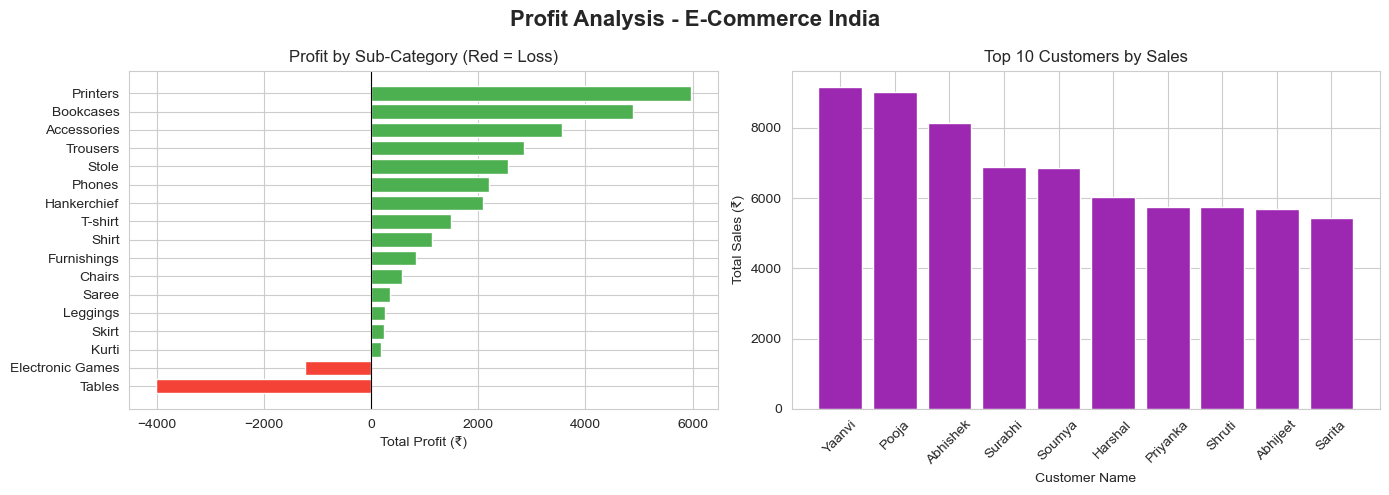

Chart 2 saved!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Profit Analysis - E-Commerce India', fontsize=16, fontweight='bold')

# Chart 5: Sub-category losses
sub_profit_all = df.groupby('Sub-Category')['Profit'].sum().reset_index()
sub_profit_all = sub_profit_all.sort_values('Profit')
colors = ['#F44336' if x < 0 else '#4CAF50' for x in sub_profit_all['Profit']]

axes[0].barh(sub_profit_all['Sub-Category'], sub_profit_all['Profit'], color=colors)
axes[0].set_title('Profit by Sub-Category (Red = Loss)')
axes[0].set_xlabel('Total Profit (₹)')
axes[0].axvline(x=0, color='black', linewidth=0.8)

# Chart 6: Top 10 customers by sales
top_customers = df.groupby('CustomerName')['Amount'].sum().reset_index()
top_customers = top_customers.sort_values('Amount', ascending=False).head(10)

axes[1].bar(top_customers['CustomerName'], top_customers['Amount'], color='#9C27B0')
axes[1].set_title('Top 10 Customers by Sales')
axes[1].set_xlabel('Customer Name')
axes[1].set_ylabel('Total Sales (₹)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../charts/profit_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")


In [7]:
print("""
===================================================
    E-COMMERCE SALES ANALYSIS - KEY FINDINGS
===================================================

1. CATEGORY PERFORMANCE
   - Electronics has highest sales (₹1,65,267) but
     Clothing is more profitable (₹11,163 vs ₹10,494)
   - Furniture has lowest profit margin despite decent sales

2. GEOGRAPHIC INSIGHTS  
   - Madhya Pradesh & Maharashtra account for ~46% of total sales
   - Top 2 states outsell the remaining 8 states combined

3. SEASONAL TRENDS
   - Peak months: January (₹61,439) and March (₹58,937)
   - July is the weakest month (₹12,966) — 79% drop from January
   - Business should plan promotions around July slump

4. LOSS-MAKING PRODUCTS
   - Tables losing ₹4,011 — pricing or cost review needed
   - Electronic Games losing ₹1,236 — consider discontinuing

5. RECOMMENDATIONS
   - Focus marketing budget on MP & Maharashtra
   - Run July discount campaigns to boost slow season
   - Review Tables pricing strategy urgently
   - Expand Clothing category — best profit margins
===================================================
""")


    E-COMMERCE SALES ANALYSIS - KEY FINDINGS

1. CATEGORY PERFORMANCE
   - Electronics has highest sales (₹1,65,267) but
     Clothing is more profitable (₹11,163 vs ₹10,494)
   - Furniture has lowest profit margin despite decent sales

2. GEOGRAPHIC INSIGHTS  
   - Madhya Pradesh & Maharashtra account for ~46% of total sales
   - Top 2 states outsell the remaining 8 states combined

3. SEASONAL TRENDS
   - Peak months: January (₹61,439) and March (₹58,937)
   - July is the weakest month (₹12,966) — 79% drop from January
   - Business should plan promotions around July slump

4. LOSS-MAKING PRODUCTS
   - Tables losing ₹4,011 — pricing or cost review needed
   - Electronic Games losing ₹1,236 — consider discontinuing

5. RECOMMENDATIONS
   - Focus marketing budget on MP & Maharashtra
   - Run July discount campaigns to boost slow season
   - Review Tables pricing strategy urgently
   - Expand Clothing category — best profit margins

